# 09 — Capacity: how much innovation model do you actually need?

The estimator learns the chain's innovation law as a mixture of $C$ components. $C$ is ours to
choose, and it is the one knob that controls how much non-Gaussianity the model can represent
at all: at $C=1$ it is a Gaussian AR(1) and the whole project reduces to a Kalman filter.

The obvious way to choose $C$ is held-out likelihood. This notebook does that, and then shows
why it is not sufficient — because the three things you might want out of the model saturate at
three different values of $C$, and the one the likelihood picks is precisely where the
between-arm generative comparison of notebook 06 reverses.

This is the notebook that notebook 06 needs; read them together.

## Three axes, three files

| axis | what it measures | where |
|---|---|---|
| **evidence** | held-out log-evidence per edge, plus cost | `outputs/exp_16/cpoint2_C*/heldout_evidence.csv` |
| **pointwise** | score error of the fitted denoiser | `outputs/exp_16/cpoint_C*/pointwise.csv` |
| **generative** | excess kurtosis of samples from the reverse SDE | `outputs/exp_16/components_C*/generation.csv` |

All at $N=2048$, three seeds for evidence, four for generation, and — this matters, and the last
section is about it — all at `em_iters=40`.

In [1]:
import sys, csv, glob, os
import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, "..")
ROOT = "../outputs/exp_16"
CS = [2, 4, 8, 12, 16]
TARGET = 1.9098   # excess kurtosis of the true (noised-channel) innovation law

def read(pat, name):
    out = {}
    for Cv in CS:
        p = os.path.join(ROOT, f"{pat}{Cv}", name)
        if os.path.exists(p):
            out[Cv] = list(csv.DictReader(open(p)))
    return out

ev  = read("cpoint2_C", "heldout_evidence.csv")
gen = read("components_C", "generation.csv")

mean = lambda rows, k: float(np.mean([float(r[k]) for r in rows]))

print(f"{'C':>3} {'params':>7} {'heldout/edge':>14} {'gain over prev':>15} {'s/iter':>8}")
print("-" * 52)
prev = None
for Cv in CS:
    he = mean(ev[Cv], "heldout_log_evidence_per_edge")
    sp = mean(ev[Cv], "em_seconds_per_iter")
    npar = int(ev[Cv][0]["n_params"])
    g = "" if prev is None else f"{he - prev:+.2e}"
    print(f"{Cv:>3} {npar:>7} {he:>14.6f} {g:>15} {sp:>8.2f}")
    prev = he

viol = sum(float(r["monotone_violation"]) for Cv in CS for r in ev[Cv])
print(f"\nmonotone EM violations across all {sum(len(ev[c]) for c in CS)} fits: {viol:.0f}")

  C  params   heldout/edge  gain over prev   s/iter
----------------------------------------------------
  2       6      -1.316948                    13.48
  4      12      -1.315194       +1.75e-03    13.84
  8      24      -1.315032       +1.62e-04    13.97
 12      36      -1.314937       +9.48e-05    13.91
 16      48      -1.314932       +5.47e-06    14.15

monotone EM violations across all 15 fits: 0


## Result 1 — evidence saturates by $C \approx 8$, and cost does not grow

The gains fall off a cliff: $1.75\times10^{-3}$, then $1.6\times10^{-4}$, then $9.5\times10^{-5}$,
then $5\times10^{-6}$. By any model-selection rule you like, nothing is bought past $C \approx 8$.

The cost column is the other half of the story and is the more surprising one. Free parameters go
from 6 to 48 — a factor of eight — while seconds per EM iteration go from 13.5 to 14.2. That is
because the E-step is $O(N n N_g^2)$ in the *grid*, and only the M-step sees $C$ at all. Capacity
here is very nearly free, which removes the usual reason to prefer the smaller model.

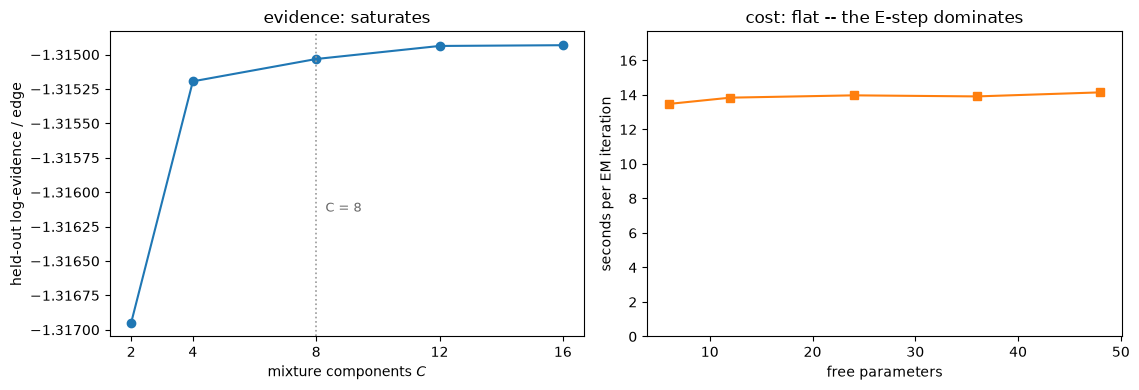

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(11.5, 4.0))

he = [mean(ev[c], "heldout_log_evidence_per_edge") for c in CS]
ax[0].plot(CS, he, "C0-o", ms=6)
ax[0].axvline(8, color="0.6", ls=":", lw=1.2)
ax[0].text(8.3, min(he) + 0.4 * (max(he) - min(he)), "C = 8", fontsize=9, color="0.4")
ax[0].set_xlabel("mixture components $C$"); ax[0].set_ylabel("held-out log-evidence / edge")
ax[0].set_title("evidence: saturates"); ax[0].set_xticks(CS)

sp = [mean(ev[c], "em_seconds_per_iter") for c in CS]
npar = [int(ev[c][0]["n_params"]) for c in CS]
ax[1].plot(npar, sp, "C1-s", ms=6)
ax[1].set_ylim(0, max(sp) * 1.25)
ax[1].set_xlabel("free parameters"); ax[1].set_ylabel("seconds per EM iteration")
ax[1].set_title("cost: flat -- the E-step dominates")
plt.tight_layout(); plt.show()

## Result 2 — the shape coordinate does *not* saturate

Held-out evidence is an average over the whole density. The thing this project is actually about
is the *shape* of the innovation law, and shape is a small correction to the likelihood: a model
can be nearly optimal in evidence while still visibly wrong in the fourth moment.

So look at the fitted kernel's own excess kurtosis against the truth it is estimating.

In [3]:
print(f"{'C':>3} {'fitted kurt':>12} {'sd over seeds':>14} {'vs target':>11}")
print("-" * 45)
for Cv in CS:
    k = [float(r["innovation_excess_kurtosis"]) for r in ev[Cv]]
    print(f"{Cv:>3} {np.mean(k):>12.3f} {np.std(k, ddof=1):>14.3f} {np.mean(k)-TARGET:>+11.3f}")
print(f"\ntarget = {TARGET}")
print("\n  Evidence says stop at 8. The fitted shape is still moving at 16, and crosses the")
print("  target somewhere between C=8 (1.761) and C=12 (2.075) -- then overshoots.")

  C  fitted kurt  sd over seeds   vs target
---------------------------------------------
  2       -0.023          0.010      -1.933
  4        1.343          0.102      -0.567
  8        1.761          0.492      -0.149
 12        2.075          0.168      +0.165
 16        2.218          0.213      +0.308

target = 1.9098

  Evidence says stop at 8. The fitted shape is still moving at 16, and crosses the
  target somewhere between C=8 (1.761) and C=12 (2.075) -- then overshoots.


## Result 3 — and the *generated* shape is systematically below the *fitted* shape

There are two different kurtoses in play and it is worth keeping them apart:

- what the **fitted kernel** says the innovation law looks like, and
- what actually comes out of the **reverse SDE** when you sample with it.

If the sampler were faithful these would agree. They do not, and the gap goes one way at every
capacity: the generated law is always blunter than the kernel that generated it.

  C  fitted kernel   generated   loss in sampling
--------------------------------------------------
  2         -0.023      -0.034              0.011
  4          1.343       0.812              0.531
  8          1.761       1.319              0.442
 12          2.075       1.363              0.712
 16          2.218       1.487              0.730


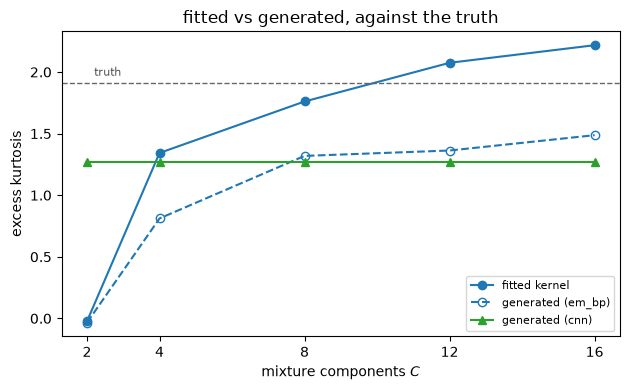

In [4]:
def gmed(Cv, arm, key="innov_kurtosis"):
    v = [float(r[key]) for r in gen[Cv] if r["arm"] == arm]
    return float(np.median(v)) if v else np.nan

print(f"{'C':>3} {'fitted kernel':>14} {'generated':>11} {'loss in sampling':>18}")
print("-" * 50)
for Cv in CS:
    fk = np.mean([float(r["innovation_excess_kurtosis"]) for r in ev[Cv]])
    gk = gmed(Cv, "em_bp")
    print(f"{Cv:>3} {fk:>14.3f} {gk:>11.3f} {fk - gk:>18.3f}")

fig, ax = plt.subplots(figsize=(6.4, 4.0))
ax.plot(CS, [np.mean([float(r["innovation_excess_kurtosis"]) for r in ev[c]]) for c in CS],
        "C0-o", ms=6, label="fitted kernel")
ax.plot(CS, [gmed(c, "em_bp") for c in CS], "C0--o", ms=6, mfc="none", label="generated (em_bp)")
ax.plot(CS, [gmed(c, "cnn") for c in CS], "C2-^", ms=6, label="generated (cnn)")
ax.axhline(TARGET, color="0.4", ls="--", lw=1); ax.set_xticks(CS)
ax.text(2.2, TARGET + 0.06, "truth", fontsize=8, color="0.3")
ax.set_xlabel("mixture components $C$"); ax.set_ylabel("excess kurtosis")
ax.set_title("fitted vs generated, against the truth"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Result 4 — where this collides with notebook 06

Notebook 06 compares EM-BP's generated law against a local CNN's and finds the CNN closer to the
truth. That comparison was run at $C=4$. The CNN has no $C$ — it is a fixed architecture, so its
generated kurtosis is a horizontal line on the plot above — while EM-BP's climbs.

In [5]:
print(f"{'C':>3} {'em_bp |d|':>11} {'cnn |d|':>9}   closer")
print("-" * 38)
flip = None
for Cv in CS:
    de, dc = abs(gmed(Cv, "em_bp") - TARGET), abs(gmed(Cv, "cnn") - TARGET)
    who = "em_bp" if de < dc else "cnn"
    if who == "em_bp" and flip is None:
        flip = Cv
    print(f"{Cv:>3} {de:>11.3f} {dc:>9.3f}   {who}")
print(f"\n  The ordering flips at C = {flip}.")
print("  Model selection on held-out evidence also lands on C = 8.")
print("  So the capacity the likelihood chooses is exactly the capacity at which the")
print("  generative comparison stops favouring the network -- which is why quoting that")
print("  comparison without stating C is not a reportable result.")

  C   em_bp |d|   cnn |d|   closer
--------------------------------------
  2       1.944     0.637   cnn
  4       1.098     0.637   cnn
  8       0.591     0.637   em_bp
 12       0.547     0.637   em_bp
 16       0.422     0.637   em_bp

  The ordering flips at C = 8.
  Model selection on held-out evidence also lands on C = 8.
  So the capacity the likelihood chooses is exactly the capacity at which the
  generative comparison stops favouring the network -- which is why quoting that
  comparison without stating C is not a reportable result.


## The confound underneath all of it

Every fit above uses `em_iters=40`. That is a fixed budget, not a convergence criterion, and
`audit/AUDIT_NOTE.md` is explicit about what fixed budgets do here:

> **A fixed iteration budget compares convergence rates, not estimators.** Whatever converges
> slower looks worse, so under-iterated runs produce apparent *deficits* rather than symmetric
> noise — which reads convincingly as a real effect.

It then lists this experiment by name: `exp_16` at `em_iters=40`, a dissociation plus a capacity
effect *"of which roughly 96% was convergence rate at a fixed budget."*

The shape coordinate is the slowest to settle — $\rho$ is converged by iteration 25, the
innovation shape needs roughly 120 — so 40 iterations is comfortably converged in the parameter
we are not measuring and not converged in the one we are. A larger $C$ has more shape parameters
to move and therefore further to travel in the same 40 steps, which produces *exactly* the
monotone "capacity effect" seen above whether or not capacity is doing anything.

The seed scatter is consistent with that reading:

In [6]:
print(f"{'C':>3} {'fitted kurt':>12} {'sd':>8} {'sd / mean':>11}")
print("-" * 38)
for Cv in CS:
    k = [float(r["innovation_excess_kurtosis"]) for r in ev[Cv]]
    m, s = np.mean(k), np.std(k, ddof=1)
    print(f"{Cv:>3} {m:>12.3f} {s:>8.3f} {abs(s/m) if m else np.nan:>11.3f}")
for line in [
    "",
    "  C=8 carries the largest absolute scatter (0.49 across three seeds) -- larger than",
    "  the C=8 -> C=16 mean movement it is supposed to resolve. Three seeds is too few to",
    "  call that, but it is what under-convergence looks like: the fits have not settled,",
    "  so where a seed lands depends on where it started.",
]:
    print(line)

  C  fitted kurt       sd   sd / mean
--------------------------------------
  2       -0.023    0.010       0.442
  4        1.343    0.102       0.076
  8        1.761    0.492       0.279
 12        2.075    0.168       0.081
 16        2.218    0.213       0.096

  C=8 carries the largest absolute scatter (0.49 across three seeds) -- larger than
  the C=8 -> C=16 mean movement it is supposed to resolve. Three seeds is too few to
  call that, but it is what under-convergence looks like: the fits have not settled,
  so where a seed lands depends on where it started.


## What to take away

1. **Held-out evidence saturates by $C \approx 8$; cost is flat.** Eight-fold more parameters buy
   5% more seconds. The usual parsimony argument for a small $C$ does not apply here.

2. **Evidence saturating does not mean the model has stopped improving where it matters.** The
   fitted innovation shape is still moving at $C=16$. Shape is a small term in an average
   log-likelihood, so an evidence plateau is weak evidence about it.

3. **Sampling loses shape.** The generated law is blunter than the fitted kernel at every
   capacity. Whatever the kernel knows, the reverse SDE does not fully transmit — which is the
   same gap notebook 06 measures from the other side.

4. **Do not quote a between-arm generative comparison without stating $C$.** The ordering flips
   at $C=8$, and $C=8$ is also what likelihood-based model selection picks.

5. **All of the above is measured at a fixed 40 EM iterations, and the project's own audit note
   attributes roughly 96% of this capacity effect to convergence rate rather than capacity.**
   The right experiment is a rerun to a convergence criterion in the shape coordinate. Until
   that exists, read every number in this notebook as an upper bound on what capacity is doing.

*Sources: `outputs/exp_16/cpoint2_C*/heldout_evidence.csv`, `components_C*/generation.csv`.
Confound: `audit/AUDIT_NOTE.md`. `exp_27_shape_convergence` is the experiment built to settle
the iteration question; its sweep was still running when this notebook was written.*